## Read .yaml files

Read Cavename.yaml files that are created with the export function `kn.io_func.nxgraph2yaml` 

Note: We used the existing yaml structure to create a data format to store and read the clean outputs of the KNdata github repository. 

The yaml file should be organized as a dictionnary of dictionnary. The mininum required is a dictionnary containing 1 key called edges, with a list of list of edges index.

The other keys that will be read by the functions are the metadata key with contains a dictionnary with several keys containing metadata related to the graph, the `edge_attributes` and `node_attributes` keys, which contains for each key a different attribute


```
{metadata:  {cavename: string
                crs: string
                original_data_rights: string
                citation: string
                ...}
 edges: list of list of edge

 edge_attributes:
    {flags:list of string
    comments:string
    ...}
 node_attributes:
    {'pos': list of float
    'fulladdress': list of string
    'idsql': list of int
    'flags': list of string
    'comments': list of string
    'splays': list of list of float
    'csdim': list of float
    ...}}}

```

In [8]:
import karstnet as kn
import networkx as nx
import matplotlib.pyplot as plt

## Importing only the edges:

In [2]:
path_to_yaml = r'..\data\047_Seefeldhoele_000\047_Seefeldhoele_000.yaml'
G = kn.io_func.networkx_from_yaml(path_to_yaml)
print(f'List of node attributes attached to the graph: {kn.utils.get_node_attribute_names(G)}')


# cavename = G.graph['short_name']
# print(f'Metadata dictionnary: {G.graph}')
# print(f'Cleaning status: {G.graph['status']}')
# print(f'Last processing date: {G.graph['last_processing_date']}')



List of node attributes attached to the graph: ['flags', 'pos', 'splays', 'idsql', 'fulladdress', 'comments', 'csdim']


## Importing all the attributes existing on nodes or edges

In [10]:
path_to_yaml = r'..\data\047_Seefeldhoele_000\047_Seefeldhoele_000.yaml'
G = kn.io_func.networkx_from_yaml(path_to_yaml,add_edge_attr=True,add_node_attr=True)

print(f'List of node attributes attached to the graph: {kn.utils.get_node_attribute_names(G)}')
print(f'List of edge attributes attached to the graph: {kn.utils.get_edge_attribute_names(G)}')


List of node attributes attached to the graph: ['flags', 'pos', 'splays', 'idsql', 'fulladdress', 'comments', 'csdim']
List of edge attributes attached to the graph: ['flags']


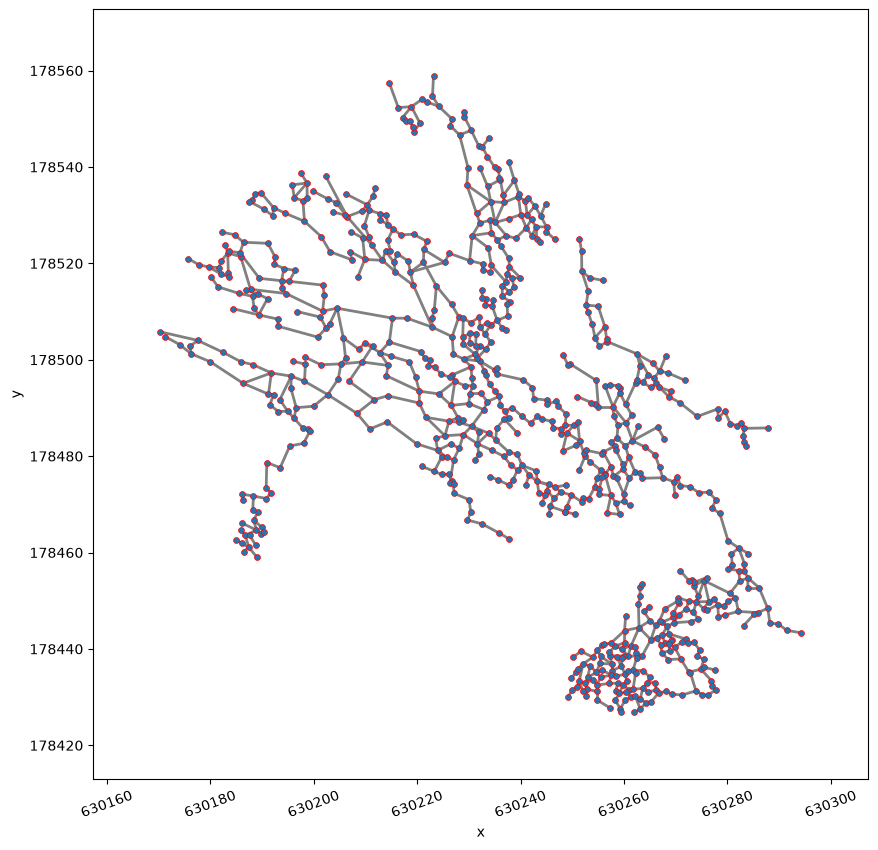

In [11]:
# Plot 2D (no node / edge property) - projection onto Oxy (default)
options = {
    'node_size'   : 18,         # node size
    'linewidths'  : 0.5,        # node border width       
    'edgecolors'  : 'red',      # node border color
    'node_color'  : 'tab:blue', # node color
    'width'       : 2,          # edge width
    'edge_color'  : 'gray',     # edge color
    'with_labels' : False,      # show node labels ?
    # 'font_size'   : 10          # font size for labels
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph2d(
    G,
    plot_nodes=True, # default is True; set to False to hide nodes
    plot_edges=True, # default is True; set to False to hide edges
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    **options
)
# # OR:
# kg.plot2d(
#     show_ticks=True, options_xaxis_ticks={'rotation':20},
#     **options
# )

plt.show()

## Importing only certain node or edge attributes:

In [14]:
import karstnet as kn
import networkx as nx
path_to_yaml = r'..\data\047_Seefeldhoele_000\047_Seefeldhoele_000.yaml'
G = kn.io_func.networkx_from_yaml(path_to_yaml,add_edge_attr=False,add_node_attr=['pos','csdim'])
# nx.draw(G,pos=kn.utils.get_pos2d(G))
print(f'List of node attributes attached to the graph: {kn.utils.get_node_attribute_names(G)}')

List of node attributes attached to the graph: ['csdim', 'pos']


## Write yaml file from graph networkx

In [15]:
kn.io_func.networkx_to_yaml(G,'../data/test_export_example.yaml')

Graph saved to yaml here: ../data/test_export_example.yaml
